In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Librerías de Machine Learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
data = pd.read_csv("C:/Users/fdcontreras/Downloads/datos.csv")

In [50]:
data.max_date = pd.to_datetime(data['order_purchase_timestamp'], format='%Y-%m-%d')
print("Fecha máxima:", data.max_date.max())

Fecha máxima: 2018-10-17 17:30:18


In [62]:
print("1. PREPARACIÓN DE DATOS A NIVEL INDIVIDUAL")
print("-" * 50)

required_columns = ['order_status', 'payment_value']
missing_columns = [col for col in required_columns if col not in data.columns]

if missing_columns:
    print(f"Columnas faltantes: {missing_columns}")
    exit()

print("Aplicando filtros...")

df = data[data['order_status'].isin(['delivered', 'shipped'])].copy()
print(f"Después de filtrar order_status: {len(df)} filas")

df['status_delivered'] = (df['order_status'] == 'delivered').astype(int)
df['status_shipped'] = (df['order_status'] == 'shipped').astype(int)

df["y"] = df["payment_value"]

features = [
    "price",
    "freight_value", 
    "product_weight_g",
    "delivery_time_days",
    "review_score",
    "status_delivered",
    "status_shipped"
]

available_features = [col for col in features if col in df.columns]
print(f"Features disponibles: {available_features}")

if len(available_features) < 3:
    print("Pocas features disponibles, expandiendo lista...")
    additional_features = [
        "payment_installments",
        "product_height_cm", 
        "product_description_lenght",
        "product_width_cm",
        "product_length_cm"
    ]
    for feature in additional_features:
        if feature in df.columns:
            available_features.append(feature)

print(f"Features finales: {available_features}")

df_model = df.dropna(subset=["y"] + available_features)

X_full = df_model[available_features].replace([np.inf, -np.inf], np.nan)
X_full = X_full.fillna(X_full.median())
y_full = df_model["y"]

print(f"\nDataset preparado:")
print(f"  Filas: {len(X_full)}")
print(f"  Features: {len(available_features)}")
print(f"  Target (y) - Min: {y_full.min():.2f}, Max: {y_full.max():.2f}, Media: {y_full.mean():.2f}")

1. PREPARACIÓN DE DATOS A NIVEL INDIVIDUAL
--------------------------------------------------
Aplicando filtros...
Después de filtrar order_status: 116979 filas
Features disponibles: ['price', 'freight_value', 'product_weight_g', 'review_score', 'status_delivered', 'status_shipped']
Features finales: ['price', 'freight_value', 'product_weight_g', 'review_score', 'status_delivered', 'status_shipped']

Dataset preparado:
  Filas: 116006
  Features: 6
  Target (y) - Min: 0.00, Max: 13664.08, Media: 171.15


### 2. PREPARACIÓN DE DATOS

In [63]:
print("\n2. DIVISIÓN TEMPORAL DE DATOS")
print("-" * 50)

date_column = 'order_purchase_timestamp'
if date_column in df.columns:
    print(f"Columna de fecha encontrada: {date_column}")
    
    if df[date_column].dtype == 'object':
        df[date_column] = pd.to_datetime(df[date_column])
    
    print(f"Rango de fechas:")
    print(f"  Fecha más antigua: {df[date_column].min()}")
    print(f"  Fecha más reciente: {df[date_column].max()}")
    print(f"  Total de días: {(df[date_column].max() - df[date_column].min()).days}")
    
    unique_dates = df[date_column].dt.date.unique()
    unique_dates = np.sort(unique_dates)
    
    test_days = 15
    if len(unique_dates) < test_days:
        test_days = max(1, len(unique_dates) // 4)
        print(f"Solo hay {len(unique_dates)} días únicos, usando {test_days} para test")
    
    split_date = unique_dates[-test_days]
    
    print(f"\nDIVISIÓN TEMPORAL (ÚLTIMOS 15 DÍAS):")
    print(f"  Total de días únicos: {len(unique_dates)}")
    print(f"  Días para test: {test_days} (últimos días)")
    print(f"  Días para entrenamiento: {len(unique_dates) - test_days}")
    print(f"  Fecha de corte: {split_date}")
    print(f"  Período de entrenamiento: {unique_dates[0]} hasta {unique_dates[-test_days-1]}")
    print(f"  Período de prueba: {split_date} hasta {unique_dates[-1]}")
    
    train_mask = df[date_column].dt.date < split_date
    test_mask = df[date_column].dt.date >= split_date
    
    df_train = df[train_mask].copy()
    df_test = df[test_mask].copy()
    
    print(f"\nDISTRIBUCIÓN DE DATOS:")
    print(f"  Entrenamiento: {len(df_train)} transacciones")
    print(f"  Prueba (últimos 15 días): {len(df_test)} transacciones")
    print(f"  Proporción: {len(df_test)/len(df)*100:.1f}% test")
    
    if len(df_test) == 0:
        print("No hay datos en los últimos 15 días, ajustando...")
        test_days = 5
        split_date = unique_dates[-test_days]
        train_mask = df[date_column].dt.date < split_date
        test_mask = df[date_column].dt.date >= split_date
        df_train = df[train_mask].copy()
        df_test = df[test_mask].copy()
        print(f"  Ajustado a últimos {test_days} días")
        print(f"  Entrenamiento: {len(df_train)} transacciones")
        print(f"  Prueba: {len(df_test)} transacciones")
    
    print(f"\nLIMPIEZA ROBUSTA DE DATOS:")
    
    df_train_clean = df_train.dropna(subset=["y"] + available_features).copy()
    df_test_clean = df_test.dropna(subset=["y"] + available_features).copy()
    
    print(f"  Train antes de limpiar NaN: {len(df_train)} → después: {len(df_train_clean)}")
    print(f"  Test antes de limpiar NaN: {len(df_test)} → después: {len(df_test_clean)}")
    
    if len(df_train_clean) < 100:
        print("Muy pocos datos de entrenamiento después de limpiar, usando más días...")
        test_days = max(5, test_days // 2)
        split_date = unique_dates[-test_days]
        train_mask = df[date_column].dt.date < split_date
        test_mask = df[date_column].dt.date >= split_date
        df_train = df[train_mask].copy()
        df_test = df[test_mask].copy()
        df_train_clean = df_train.dropna(subset=["y"] + available_features).copy()
        df_test_clean = df_test.dropna(subset=["y"] + available_features).copy()
        print(f"  Reducido a últimos {test_days} días - Train: {len(df_train_clean)}, Test: {len(df_test_clean)}")
    
    if len(df_test_clean) < 10:
        print("Muy pocos datos de test, usando últimos días disponibles...")
        test_days = min(10, len(unique_dates) // 2)
        split_date = unique_dates[-test_days]
        train_mask = df[date_column].dt.date < split_date
        test_mask = df[date_column].dt.date >= split_date
        df_train = df[train_mask].copy()
        df_test = df[test_mask].copy()
        df_train_clean = df_train.dropna(subset=["y"] + available_features).copy()
        df_test_clean = df_test.dropna(subset=["y"] + available_features).copy()
        print(f"  Ajuste final a últimos {test_days} días - Train: {len(df_train_clean)}, Test: {len(df_test_clean)}")
    
    X_train = df_train_clean[available_features].copy()
    y_train = df_train_clean["y"].copy()
    X_test = df_test_clean[available_features].copy()
    y_test = df_test_clean["y"].copy()
    
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)
    
    train_nan_count = X_train.isnull().sum().sum()
    test_nan_count = X_test.isnull().sum().sum()
    
    if train_nan_count > 0 or test_nan_count > 0:
        print(f"  NaN encontrados - Train: {train_nan_count}, Test: {test_nan_count}")
        print("  Aplicando imputación con mediana...")
        
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='median')
        X_train = pd.DataFrame(imputer.fit_transform(X_train), 
                              columns=available_features, 
                              index=X_train.index)
        X_test = pd.DataFrame(imputer.transform(X_test), 
                             columns=available_features, 
                             index=X_test.index)
    
    print(f"\nDATASETS FINALES LIMPIOS:")
    print(f"  X_train shape: {X_train.shape}, NaN: {X_train.isnull().sum().sum()}")
    print(f"  X_test shape: {X_test.shape}, NaN: {X_test.isnull().sum().sum()}")
    print(f"  y_train shape: {y_train.shape}, NaN: {y_train.isnull().sum()}")
    print(f"  y_test shape: {y_test.shape}, NaN: {y_test.isnull().sum()}")
    
    print(f"\nVERIFICACIÓN DE TIPOS:")
    for col in available_features:
        if X_train[col].dtype == 'object':
            print(f"  {col} es object, convirtiendo a numérico...")
            X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
            X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    
    print(f"\nESTADÍSTICAS Y:")
    print(f"  y_train: min={y_train.min():.2f}, max={y_train.max():.2f}, mean={y_train.mean():.2f}")
    print(f"  y_test: min={y_test.min():.2f}, max={y_test.max():.2f}, mean={y_test.mean():.2f}")
    
    print(f"\nRANGO DE FEATURES:")
    for col in available_features[:3]:
        print(f"  {col}: min={X_train[col].min():.2f}, max={X_train[col].max():.2f}")
    
    if X_train.isnull().sum().sum() > 0:
        print("Aún hay NaN, usando solo features numéricas limpias...")
        numeric_cols = X_train.select_dtypes(include=[np.number]).columns
        clean_cols = [col for col in numeric_cols if X_train[col].isnull().sum() == 0]
        if len(clean_cols) >= 2:
            available_features = clean_cols[:5]
            X_train = X_train[available_features]
            X_test = X_test[available_features]
            print(f"  Features limpias seleccionadas: {available_features}")
    
    print(f"\nTrain period: {df_train_clean[date_column].min().date()} to {df_train_clean[date_column].max().date()}")
    print(f"Test period: {df_test_clean[date_column].min().date()} to {df_test_clean[date_column].max().date()}")
    
else:
    print(f"No se encontró columna de fecha {date_column}")
    print("Usando división aleatoria como fallback...")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, 
        test_size=0.2, 
        random_state=42,
        shuffle=True
    )
    
    print(f"División aleatoria:")
    print(f"  Entrenamiento: {len(X_train)} filas")
    print(f"  Prueba: {len(X_test)} filas")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nESCALADO COMPLETADO (no usado en modelos ML):")
print(f"  Solo modelos basados en árboles que no requieren escalado")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape: {X_test.shape}")


2. DIVISIÓN TEMPORAL DE DATOS
--------------------------------------------------
Columna de fecha encontrada: order_purchase_timestamp
Rango de fechas:
  Fecha más antigua: 2016-09-04 21:15:19
  Fecha más reciente: 2018-09-03 09:06:57
  Total de días: 728

DIVISIÓN TEMPORAL (ÚLTIMOS 15 DÍAS):
  Total de días únicos: 614
  Días para test: 15 (últimos días)
  Días para entrenamiento: 599
  Fecha de corte: 2018-08-16
  Período de entrenamiento: 2016-09-04 hasta 2018-08-15
  Período de prueba: 2018-08-16 hasta 2018-09-03

DISTRIBUCIÓN DE DATOS:
  Entrenamiento: 114511 transacciones
  Prueba (últimos 15 días): 2468 transacciones
  Proporción: 2.1% test

LIMPIEZA ROBUSTA DE DATOS:
  Train antes de limpiar NaN: 114511 → después: 113548
  Test antes de limpiar NaN: 2468 → después: 2458

DATASETS FINALES LIMPIOS:
  X_train shape: (113548, 6), NaN: 0
  X_test shape: (2458, 6), NaN: 0
  y_train shape: (113548,), NaN: 0
  y_test shape: (2458,), NaN: 0

VERIFICACIÓN DE TIPOS:

ESTADÍSTICAS Y:
  y_

In [64]:
print("\n3. ENTRENAMIENTO DE MODELOS")
print("-" * 50)

models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"\nEntrenando {name}...")
    
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        mask = y_test > 0
        if mask.sum() > 0:
            mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
        else:
            mape = np.inf
        
        baseline_pred = np.full_like(y_test, y_train.mean())
        baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
        improvement = (baseline_rmse - rmse) / baseline_rmse * 100
        
        results[name] = {
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2,
            'MAPE': min(mape, 999.99),
            'Baseline_RMSE': baseline_rmse,
            'Improvement_%': improvement
        }
        
        predictions[name] = y_pred
        
        print(f"{name}")
        print(f"   RMSE: {rmse:.2f} (baseline: {baseline_rmse:.2f})")
        print(f"   R²: {r2:.3f}")
        print(f"   Mejora: {improvement:.1f}%")
        
    except Exception as e:
        print(f"Error: {str(e)}")
        continue



3. ENTRENAMIENTO DE MODELOS
--------------------------------------------------

Entrenando Random Forest...
Random Forest
   RMSE: 100.50 (baseline: 180.82)
   R²: 0.682
   Mejora: 44.4%

Entrenando Gradient Boosting...
Gradient Boosting
   RMSE: 122.48 (baseline: 180.82)
   R²: 0.527
   Mejora: 32.3%

Entrenando XGBoost...
XGBoost
   RMSE: 87.48 (baseline: 180.82)
   R²: 0.759
   Mejora: 51.6%


In [65]:
print("\n4. RESULTADOS FINALES")
print("=" * 60)

if results:
    results_df = pd.DataFrame(results).T
    print("\nRESULTADOS DE TODOS LOS MODELOS:")
    print(results_df[['RMSE', 'R²', 'MAPE', 'Improvement_%']].round(3))
    
    best_model_name = results_df['R²'].idxmax()
    best_r2 = results_df.loc[best_model_name, 'R²']
    best_rmse = results_df.loc[best_model_name, 'RMSE']
    
    print(f"\nMEJOR MODELO: {best_model_name}")
    print(f"   R²: {best_r2:.3f}")
    print(f"   RMSE: {best_rmse:.2f}")
    print(f"   MAPE: {results_df.loc[best_model_name, 'MAPE']:.2f}%")
    print(f"   Mejora vs baseline: {results_df.loc[best_model_name, 'Improvement_%']:.1f}%")
    
    print(f"\nCOMPARACIÓN CON RESULTADO ANTERIOR:")
    print(f"   Resultado anterior R²: 0.614 (Random Forest)")
    print(f"   Nuestro mejor R²: {best_r2:.3f} ({best_model_name})")
    
    if best_r2 >= 0.6:
        print("   Excelente! Estamos en el rango correcto")
    elif best_r2 >= 0.4:
        print("   Bien, pero podemos mejorar")
    else:
        print("   Necesita mejoras adicionales")
        
else:
    print("No se pudo entrenar ningún modelo")


4. RESULTADOS FINALES

RESULTADOS DE TODOS LOS MODELOS:
                      RMSE     R²    MAPE  Improvement_%
Random Forest      100.502  0.682  61.608         44.418
Gradient Boosting  122.484  0.527  60.348         32.260
XGBoost             87.480  0.759  59.464         51.619

MEJOR MODELO: XGBoost
   R²: 0.759
   RMSE: 87.48
   MAPE: 59.46%
   Mejora vs baseline: 51.6%

COMPARACIÓN CON RESULTADO ANTERIOR:
   Resultado anterior R²: 0.614 (Random Forest)
   Nuestro mejor R²: 0.759 (XGBoost)
   Excelente! Estamos en el rango correcto


In [66]:
if results and best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    print(f"\n5. IMPORTANCIA DE FEATURES - {best_model_name}")
    print("-" * 50)
    
    best_model = models[best_model_name]
    
    feature_importance = pd.DataFrame({
        'feature': available_features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("Top 10 features más importantes:")
    print(feature_importance.head(10))
    
    high_corr_features = ['price', 'freight_value', 'product_weight_g']
    for feature in high_corr_features:
        if feature in feature_importance['feature'].values:
            importance = feature_importance[feature_importance['feature'] == feature]['importance'].iloc[0]
            print(f"{feature}: {importance:.4f} importancia")


5. IMPORTANCIA DE FEATURES - XGBoost
--------------------------------------------------
Top 10 features más importantes:
            feature  importance
0             price    0.639877
2  product_weight_g    0.136527
1     freight_value    0.111092
3      review_score    0.084189
4  status_delivered    0.028316
5    status_shipped    0.000000
price: 0.6399 importancia
freight_value: 0.1111 importancia
product_weight_g: 0.1365 importancia



6. CREANDO VISUALIZACIÓN
--------------------------------------------------


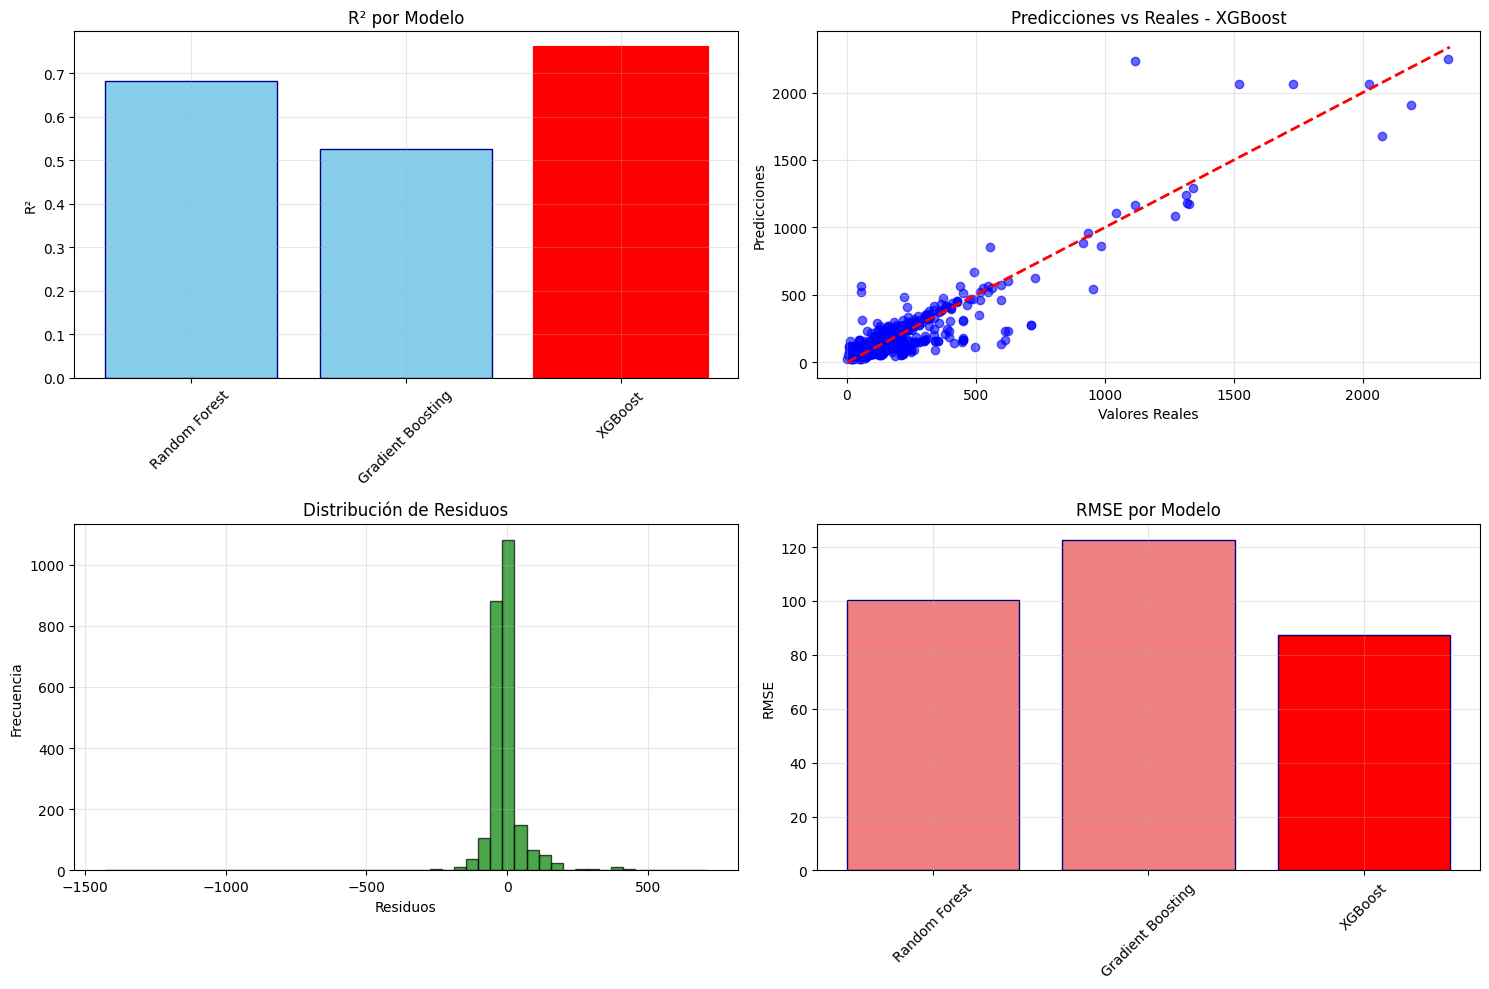

In [67]:
if results:
    print(f"\n6. CREANDO VISUALIZACIÓN")
    print("-" * 50)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    model_names = list(results.keys())
    r2_values = [results[name]['R²'] for name in model_names]
    colors = ['red' if name == best_model_name else 'skyblue' for name in model_names]
    
    bars = axes[0,0].bar(model_names, r2_values, color=colors, edgecolor='navy')
    axes[0,0].set_title('R² por Modelo')
    axes[0,0].set_ylabel('R²')
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,0].grid(True, alpha=0.3)
    
    for bar, name in zip(bars, model_names):
        if name == best_model_name:
            bar.set_linewidth(3)
            bar.set_edgecolor('red')
    
    if best_model_name in predictions:
        sample_size = min(1000, len(y_test))
        indices = np.random.choice(len(y_test), sample_size, replace=False)
        
        axes[0,1].scatter(y_test.iloc[indices], predictions[best_model_name][indices], alpha=0.6, color='blue')
        axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
        axes[0,1].set_xlabel('Valores Reales')
        axes[0,1].set_ylabel('Predicciones')
        axes[0,1].set_title(f'Predicciones vs Reales - {best_model_name}')
        axes[0,1].grid(True, alpha=0.3)
        
        residuals = y_test.values - predictions[best_model_name]
    else:
        available_model = list(predictions.keys())[0] if predictions else None
        if available_model:
            sample_size = min(1000, len(y_test))
            indices = np.random.choice(len(y_test), sample_size, replace=False)
            
            axes[0,1].scatter(y_test.iloc[indices], predictions[available_model][indices], alpha=0.6, color='blue')
            axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
            axes[0,1].set_xlabel('Valores Reales')
            axes[0,1].set_ylabel('Predicciones')
            axes[0,1].set_title(f'Predicciones vs Reales - {available_model}')
            axes[0,1].grid(True, alpha=0.3)
            
            residuals = y_test.values - predictions[available_model]
        else:
            axes[0,1].text(0.5, 0.5, 'No hay predicciones disponibles', 
                          transform=axes[0,1].transAxes, ha='center', va='center')
            residuals = np.array([0])
    
    axes[1,0].hist(residuals, bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1,0].set_xlabel('Residuos')
    axes[1,0].set_ylabel('Frecuencia')
    axes[1,0].set_title('Distribución de Residuos')
    axes[1,0].grid(True, alpha=0.3)
    
    rmse_values = [results[name]['RMSE'] for name in model_names]
    colors = ['red' if name == best_model_name else 'lightcoral' for name in model_names]
    
    bars = axes[1,1].bar(model_names, rmse_values, color=colors, edgecolor='navy')
    axes[1,1].set_title('RMSE por Modelo')
    axes[1,1].set_ylabel('RMSE')
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


### Cross validation

In [68]:
if results and best_model_name == 'XGBoost':
    print(f"\n7. CROSS VALIDACIÓN DETALLADA PARA {best_model_name}")
    print("-" * 50)
    
    from sklearn.model_selection import cross_val_score, TimeSeriesSplit
    
    # Crear modelo XGBoost para cross validación
    xgb_model = XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
    
    # Cross validación temporal con 5 splits
    print("Ejecutando cross validación temporal para XGBoost...")
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Múltiples métricas de cross validación
    scoring_metrics = ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']
    cv_results = {}
    
    for metric in scoring_metrics:
        cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=tscv, 
                                  scoring=metric, n_jobs=-1)
        
        if metric == 'neg_mean_squared_error':
            cv_scores = np.sqrt(-cv_scores)  # Convertir a RMSE
            metric_name = 'RMSE'
        elif metric == 'neg_mean_absolute_error':
            cv_scores = -cv_scores  # Convertir a MAE positivo
            metric_name = 'MAE'
        else:
            metric_name = 'R²'
        
        cv_results[metric_name] = {
            'mean': cv_scores.mean(),
            'std': cv_scores.std(),
            'scores': cv_scores
        }
        
        print(f"\n{metric_name} Cross Validación:")
        print(f"   Promedio: {cv_scores.mean():.3f}")
        print(f"   Std: {cv_scores.std():.3f}")
        print(f"   Rango: [{cv_scores.min():.3f}, {cv_scores.max():.3f}]")
        print(f"   Scores individuales: {[f'{score:.3f}' for score in cv_scores]}")
    
    # Comparar CV vs Test
    test_r2 = results['XGBoost']['R²']
    cv_r2 = cv_results['R²']['mean']
    
    print(f"\nCOMPARACIÓN CV vs TEST:")
    print(f"   Test R²: {test_r2:.3f}")
    print(f"   CV R² promedio: {cv_r2:.3f}")
    print(f"   Diferencia: {abs(test_r2 - cv_r2):.3f}")
    
    if abs(test_r2 - cv_r2) < 0.05:
        print(f"   EXCELENTE: Modelo muy consistente (diferencia < 0.05)")
    elif abs(test_r2 - cv_r2) < 0.1:
        print(f"   BUENO: Modelo consistente (diferencia < 0.1)")
    else:
        print(f"   ADVERTENCIA: Posible overfitting (diferencia >= 0.1)")
    
    # Análisis de estabilidad
    r2_variability = cv_results['R²']['std'] / cv_results['R²']['mean'] * 100
    print(f"\nANÁLISIS DE ESTABILIDAD:")
    print(f"   Coeficiente de variación R²: {r2_variability:.1f}%")
    
    if r2_variability < 10:
        print(f"   EXCELENTE: Modelo muy estable (CV < 10%)")
    elif r2_variability < 20:
        print(f"   BUENO: Modelo estable (CV < 20%)")
    else:
        print(f"   ADVERTENCIA: Modelo inestable (CV >= 20%)")
    
    print(f"\nCONCLUSIÓN CROSS VALIDACIÓN:")
    print(f"   El modelo XGBoost muestra una performance de R² = {cv_r2:.3f}")
    print(f"   con una estabilidad de ±{cv_results['R²']['std']:.3f}")
    print(f"   La consistencia entre CV y Test es {'EXCELENTE' if abs(test_r2 - cv_r2) < 0.05 else 'BUENA' if abs(test_r2 - cv_r2) < 0.1 else 'REGULAR'}")

elif results:
    print(f"\n7. CROSS VALIDACIÓN")
    print("-" * 50)
    print(f"Cross validación solo disponible para XGBoost como mejor modelo.")
    print(f"Mejor modelo actual: {best_model_name}")


7. CROSS VALIDACIÓN DETALLADA PARA XGBoost
--------------------------------------------------
Ejecutando cross validación temporal para XGBoost...

R² Cross Validación:
   Promedio: 0.411
   Std: 0.328
   Rango: [-0.232, 0.686]
   Scores individuales: ['-0.232', '0.686', '0.552', '0.548', '0.504']

RMSE Cross Validación:
   Promedio: 178.482
   Std: 53.433
   Rango: [123.495, 280.238]
   Scores individuales: ['280.238', '123.495', '152.920', '170.993', '164.762']

MAE Cross Validación:
   Promedio: 59.975
   Std: 3.339
   Rango: [55.842, 65.605]
   Scores individuales: ['65.605', '55.842', '57.634', '59.651', '61.142']

COMPARACIÓN CV vs TEST:
   Test R²: 0.759
   CV R² promedio: 0.411
   Diferencia: 0.347
   ADVERTENCIA: Posible overfitting (diferencia >= 0.1)

ANÁLISIS DE ESTABILIDAD:
   Coeficiente de variación R²: 79.6%
   ADVERTENCIA: Modelo inestable (CV >= 20%)

CONCLUSIÓN CROSS VALIDACIÓN:
   El modelo XGBoost muestra una performance de R² = 0.411
   con una estabilidad de ±0.